# Dataset collection


### Dataset description

Dataset consists of visible, radar, and NDVI imagery. Dataset is from the satellites Sentinel 1 and 2. Data was retrieved from [Mendeley](https://data.mendeley.com/datasets/xjcr5k4c9t/3), which isn't the source of the Sentinel 1 and 2 data, but as a pilot study to reduce project
complexity this model will be built only using dataset.

In the future it might be worth looking at the pacific islands and evaluating my model specifically there, since that will be the main focus of the final
version of this project. Sentinel 1 and 2 data are available from [the browser site for copernicus](https://browser.dataspace.copernicus.eu/?zoom=11&lat=45.36638&lng=12.49832&themeId=DEFAULT-THEME&visualizationUrl=U2FsdGVkX18LlqQWm6QqJgNFUmb23sCe6l0jBVu4bmuXzbmu6dtOoMdbTpz9a2hHctGwpNt8jjs5Cm7P%2BA6Df0N99Gxo92y0z3XbbPV%2BMzmpToEP92QCVJVh90ab2xgP&datasetId=S2_L1C_CDAS&fromTime=2023-02-07T00%3A00%3A00.000Z&toTime=2023-02-07T23%3A59%3A59.999Z&layerId=1_TRUE_COLOR&demSource3D=%22MAPZEN%22&cloudCoverage=10&dateMode=SINGLE).


### Loading Data + Imports

In [4]:
# Imports
import os
from PIL import Image
from matplotlib import pyplot as plt
import random
from PIL.TiffTags import TAGS
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [5]:
# Filepaths for each modality
data_folder = "Data/"
NDVI_path = "NDVI/"
RGB_path = "RGB/"
VV_path = "VV/"
VH_path = "VH/"
csv_path = "DATA.csv"
file_list = os.listdir(os.path.join(data_folder, NDVI_path))
file_list[0:5]

['0A.tif', '0B.tif', '1000A.tif', '1000B.tif', '1001A.tif']

In [6]:
random_file_index = random.randint(0, len(file_list))
loaded_file = file_list[random_file_index] # Get a random file 
loaded_file 

'394B.tif'

In [7]:
# Load an image for each modality as well as csv file
NDVI_image = Image.open(os.path.join(data_folder, NDVI_path, loaded_file))
RGB_image = Image.open(os.path.join(data_folder, RGB_path, loaded_file))
VV_image = Image.open(os.path.join(data_folder, VV_path, loaded_file))
VH_image = Image.open(os.path.join(data_folder, VH_path, loaded_file))
df = pd.read_csv(os.path.join(data_folder, csv_path))
df

,Unnamed: 0,Initial dates,End dates,Latitud,Longitudes,Cloudiness Mean,Water percentage Mean,Vegetation percentage Mean
0,0,2021-5-28,2021-8-28,-27.178578,-61.344276,0.557070,0.005319,35.276470
1,1,2019-6-22,2019-9-22,-13.501406,-69.013707,2.929528,0.533353,93.824572
2,2,2023-9-18,2023-12-18,-4.504011,-59.313504,1.934562,7.026944,79.781830
3,3,2021-2-22,2021-5-22,-18.441324,123.385166,0.199029,0.036947,27.204141
4,4,2023-4-28,2023-7-28,-12.400100,38.724987,2.452178,0.005001,81.946476
...,...,...,...,...,...,...,...,...
1095,1095,2020-7-21,2020-10-21,-4.479845,19.401024,3.689563,1.508436,33.546647
1096,1096,2019-6-3,2019-9-3,-27.901399,-51.256896,1.508865,1.557228,84.433976
1097,1097,2019-4-13,2019-7-13,-19.140108,143.448729,0.736642,0.004024,51.760488
1098,1098,2022-9-11,2022-12-11,-12.994914,37.351082,2.901172,0.000009,34.256643


In [8]:
# To make things easier, we're also going to add in the ID for each image.
df = df.drop(columns="Unnamed: 0")
df["ID_A"] = pd.Series(df.index).astype(dtype=str) + "A.tif"
df["ID_B"] = pd.Series(df.index).astype(dtype=str) + "B.tif"
df

,Initial dates,End dates,Latitud,Longitudes,Cloudiness Mean,Water percentage Mean,Vegetation percentage Mean,ID_A,ID_B
0,2021-5-28,2021-8-28,-27.178578,-61.344276,0.557070,0.005319,35.276470,0A.tif,0B.tif
1,2019-6-22,2019-9-22,-13.501406,-69.013707,2.929528,0.533353,93.824572,1A.tif,1B.tif
2,2023-9-18,2023-12-18,-4.504011,-59.313504,1.934562,7.026944,79.781830,2A.tif,2B.tif
3,2021-2-22,2021-5-22,-18.441324,123.385166,0.199029,0.036947,27.204141,3A.tif,3B.tif
4,2023-4-28,2023-7-28,-12.400100,38.724987,2.452178,0.005001,81.946476,4A.tif,4B.tif
...,...,...,...,...,...,...,...,...,...
1095,2020-7-21,2020-10-21,-4.479845,19.401024,3.689563,1.508436,33.546647,1095A.tif,1095B.tif
1096,2019-6-3,2019-9-3,-27.901399,-51.256896,1.508865,1.557228,84.433976,1096A.tif,1096B.tif
1097,2019-4-13,2019-7-13,-19.140108,143.448729,0.736642,0.004024,51.760488,1097A.tif,1097B.tif
1098,2022-9-11,2022-12-11,-12.994914,37.351082,2.901172,0.000009,34.256643,1098A.tif,1098B.tif


In [9]:
df["Time diff (days)"] = pd.to_datetime(df["End dates"]) - pd.to_datetime(df["Initial dates"])
df["Time diff (days)"] = df["Time diff (days)"].dt.days
df

,Initial dates,End dates,Latitud,Longitudes,Cloudiness Mean,Water percentage Mean,Vegetation percentage Mean,ID_A,ID_B,Time diff (days)
0,2021-5-28,2021-8-28,-27.178578,-61.344276,0.557070,0.005319,35.276470,0A.tif,0B.tif,92
1,2019-6-22,2019-9-22,-13.501406,-69.013707,2.929528,0.533353,93.824572,1A.tif,1B.tif,92
2,2023-9-18,2023-12-18,-4.504011,-59.313504,1.934562,7.026944,79.781830,2A.tif,2B.tif,91
3,2021-2-22,2021-5-22,-18.441324,123.385166,0.199029,0.036947,27.204141,3A.tif,3B.tif,89
4,2023-4-28,2023-7-28,-12.400100,38.724987,2.452178,0.005001,81.946476,4A.tif,4B.tif,91
...,...,...,...,...,...,...,...,...,...,...
1095,2020-7-21,2020-10-21,-4.479845,19.401024,3.689563,1.508436,33.546647,1095A.tif,1095B.tif,92
1096,2019-6-3,2019-9-3,-27.901399,-51.256896,1.508865,1.557228,84.433976,1096A.tif,1096B.tif,92
1097,2019-4-13,2019-7-13,-19.140108,143.448729,0.736642,0.004024,51.760488,1097A.tif,1097B.tif,91
1098,2022-9-11,2022-12-11,-12.994914,37.351082,2.901172,0.000009,34.256643,1098A.tif,1098B.tif,91


In [10]:
pd.Series(df.index)

0          0
1          1
2          2
3          3
4          4
        ... 
1095    1095
1096    1096
1097    1097
1098    1098
1099    1099
Length: 1100, dtype: int64

In [11]:
print("NDVI Metadata")
for header in NDVI_image.tag:
    print(f'{TAGS[header]}: {NDVI_image.tag_v2[header]}')

NDVI Metadata
ImageWidth: 512
ImageLength: 512
BitsPerSample: (32,)
Compression: 1
PhotometricInterpretation: 1
StripOffsets: (8, 8200, 16392, 24584, 32776, 40968, 49160, 57352, 65544, 73736, 81928, 90120, 98312, 106504, 114696, 122888, 131080, 139272, 147464, 155656, 163848, 172040, 180232, 188424, 196616, 204808, 213000, 221192, 229384, 237576, 245768, 253960, 262152, 270344, 278536, 286728, 294920, 303112, 311304, 319496, 327688, 335880, 344072, 352264, 360456, 368648, 376840, 385032, 393224, 401416, 409608, 417800, 425992, 434184, 442376, 450568, 458760, 466952, 475144, 483336, 491528, 499720, 507912, 516104, 524296, 532488, 540680, 548872, 557064, 565256, 573448, 581640, 589832, 598024, 606216, 614408, 622600, 630792, 638984, 647176, 655368, 663560, 671752, 679944, 688136, 696328, 704520, 712712, 720904, 729096, 737288, 745480, 753672, 761864, 770056, 778248, 786440, 794632, 802824, 811016, 819208, 827400, 835592, 843784, 851976, 860168, 868360, 876552, 884744, 892936, 901128, 909

In [12]:
print("RGB Metadata")
for header in RGB_image.tag:
    print(f'{TAGS[header]}: {RGB_image.tag_v2[header]}')

RGB Metadata
ImageWidth: 512
ImageLength: 512
BitsPerSample: (8, 8, 8)
Compression: 5
PhotometricInterpretation: 2
StripOffsets: (8, 6017, 12024, 18051, 24033, 29955, 35888, 41710, 47634, 53506, 59573, 65672, 71671, 77655, 83463, 89036, 94659, 100404, 106128, 111781, 117555, 123337, 129067, 134475, 139955, 145343, 150657, 155995, 161341, 166648, 171905, 177062, 182204, 187394, 192675, 197952, 203184, 208293, 213310, 218321, 223379, 228470, 233637, 238956, 244165, 249502, 254761, 259940, 265124, 270267, 275407, 280604, 285977, 291275, 296510, 301767, 307453, 312949, 318289, 323579, 329038, 334519, 340293, 346082, 351986, 357989, 364182, 370367, 376494, 382349, 388382, 394346, 400208, 405817, 411466, 417105, 422736, 428411, 433803, 439122, 444453, 449785, 455050, 460288, 465569, 471006, 476395, 481938, 487535, 493050, 498526, 503902, 509276, 514737, 520095, 525382, 530669, 535937, 541382, 546946, 552404, 557747, 563052)
SampleFormat: (1, 1, 1)
SamplesPerPixel: 3
RowsPerStrip: 5
StripByte

In [13]:
print("VV Metadata")
for header in VV_image.tag:
    print(f'{TAGS[header]}: {VV_image.tag_v2[header]}')

VV Metadata
ImageWidth: 512
ImageLength: 512
BitsPerSample: (8, 8, 8)
Compression: 5
PhotometricInterpretation: 2
StripOffsets: (8, 3336, 6639, 9919, 13195, 16478, 19758, 23058, 26298, 29553, 32847, 36184, 39509, 42819, 46146, 49441, 52727, 56033, 59382, 62688, 65958, 69250, 72571, 75934, 79229, 82566, 85824, 89130, 92416, 95683, 98900, 102192, 105493, 108790, 112141, 115478, 118812, 122058, 125346, 128604, 131917, 135224, 138489, 141817, 145079, 148385, 151643, 154865, 158166, 161422, 164686, 167972, 171239, 174495, 177778, 181040, 184319, 187596, 190858, 194153, 197439, 200775, 204093, 207424, 210757, 214058, 217377, 220656, 223966, 227222, 230538, 233827, 237152, 240458, 243798, 247102, 250430, 253743, 257077, 260369, 263690, 267015, 270306, 273592, 276929, 280223, 283569, 286920, 290268, 293599, 296956, 300355, 303713, 307071, 310401, 313734, 317086, 320446, 323822, 327131, 330432, 333735, 337057)
SampleFormat: (1, 1, 1)
SamplesPerPixel: 3
RowsPerStrip: 5
StripByteCounts: (3328, 33

In [14]:
print("VH Metadata")
for header in VV_image.tag:
    print(f'{TAGS[header]}: {VV_image.tag_v2[header]}')

VH Metadata
ImageWidth: 512
ImageLength: 512
BitsPerSample: (8, 8, 8)
Compression: 5
PhotometricInterpretation: 2
StripOffsets: (8, 3336, 6639, 9919, 13195, 16478, 19758, 23058, 26298, 29553, 32847, 36184, 39509, 42819, 46146, 49441, 52727, 56033, 59382, 62688, 65958, 69250, 72571, 75934, 79229, 82566, 85824, 89130, 92416, 95683, 98900, 102192, 105493, 108790, 112141, 115478, 118812, 122058, 125346, 128604, 131917, 135224, 138489, 141817, 145079, 148385, 151643, 154865, 158166, 161422, 164686, 167972, 171239, 174495, 177778, 181040, 184319, 187596, 190858, 194153, 197439, 200775, 204093, 207424, 210757, 214058, 217377, 220656, 223966, 227222, 230538, 233827, 237152, 240458, 243798, 247102, 250430, 253743, 257077, 260369, 263690, 267015, 270306, 273592, 276929, 280223, 283569, 286920, 290268, 293599, 296956, 300355, 303713, 307071, 310401, 313734, 317086, 320446, 323822, 327131, 330432, 333735, 337057)
SampleFormat: (1, 1, 1)
SamplesPerPixel: 3
RowsPerStrip: 5
StripByteCounts: (3328, 33

##### Metadata Findings

NDVI - Stored as a 32 bit 1 channel image where the minimum value corresponds to white (Photometric Interpretation 1). 

Other data is stored as RGB (with 8, 8, 8 bitspersample and photometric interpretation 2).


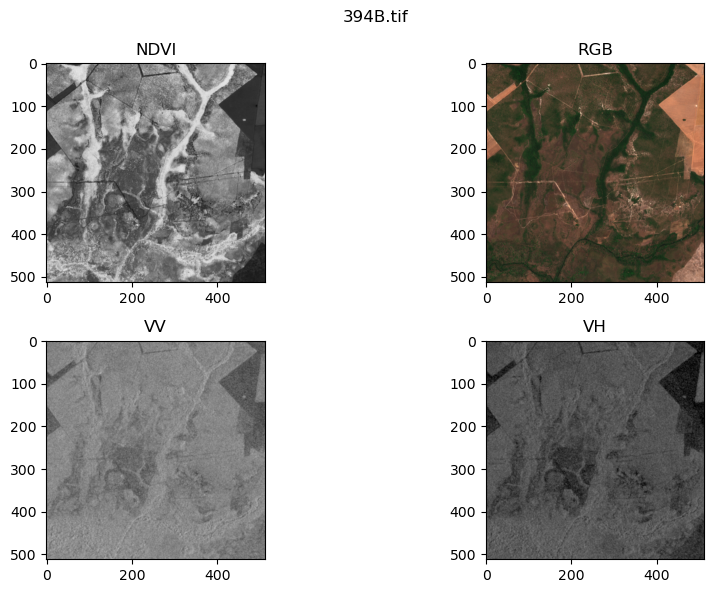

In [16]:
fig, ax = plt.subplots(2, 2, figsize=(10, 6))
plt.suptitle(loaded_file)
ax[0, 0].imshow(Image.fromarray(np.asarray(NDVI_image) * 255))
ax[0, 0].set_title("NDVI")
ax[0, 1].imshow(RGB_image)
ax[0, 1].set_title("RGB")
ax[1, 0].imshow(VV_image)
ax[1, 0].set_title("VV")
ax[1, 1].imshow(VH_image)
ax[1, 1].set_title("VH")
plt.tight_layout()
plt.show()

# Exploratory Data Analysis

The exploratory data anlysis of these images will be separated into three sections: Overall metadata analysis, dataset validation, and correlation analysis.

### Metadata Analysis

For the machine learning applications of this project, we need the data counts to all match, as well as to keep track of any common properties between the metadata. Both the GeoTIFF metadata + the csv loaded will be analyzed. 

In [19]:
print(f"{len(file_list)} images of every modality")
print(f"{len(df)} entries in the DATA.csv")

2200 images of every modality
1100 entries in the DATA.csv


In [20]:
df.describe()

,Latitud,Longitudes,Cloudiness Mean,Water percentage Mean,Vegetation percentage Mean,Time diff (days)
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,-0.308794,10.042380,1.159264,3.255626,60.767561,91.296364
std,23.590904,76.188747,0.933690,7.374210,24.100159,0.982738
min,-39.997314,-123.520803,0.000000,0.000000,20.106609,89.000000
25%,-18.699107,-57.968152,0.475050,0.082049,39.557610,91.000000
50%,-7.179332,19.427016,0.948784,0.421795,59.705644,92.000000
75%,22.934320,73.879497,1.604131,1.716117,83.592651,92.000000
max,39.934311,177.727062,4.997472,39.609063,99.604738,92.000000


This means that there are 1100 locations/times being studied with each satellite, and there are two groups of satellites A and B. Checks out with the file names since there's files \<ID\>A and \<ID\>B, making up 2200 images of every modality.

In [22]:
df

,Initial dates,End dates,Latitud,Longitudes,Cloudiness Mean,Water percentage Mean,Vegetation percentage Mean,ID_A,ID_B,Time diff (days)
0,2021-5-28,2021-8-28,-27.178578,-61.344276,0.557070,0.005319,35.276470,0A.tif,0B.tif,92
1,2019-6-22,2019-9-22,-13.501406,-69.013707,2.929528,0.533353,93.824572,1A.tif,1B.tif,92
2,2023-9-18,2023-12-18,-4.504011,-59.313504,1.934562,7.026944,79.781830,2A.tif,2B.tif,91
3,2021-2-22,2021-5-22,-18.441324,123.385166,0.199029,0.036947,27.204141,3A.tif,3B.tif,89
4,2023-4-28,2023-7-28,-12.400100,38.724987,2.452178,0.005001,81.946476,4A.tif,4B.tif,91
...,...,...,...,...,...,...,...,...,...,...
1095,2020-7-21,2020-10-21,-4.479845,19.401024,3.689563,1.508436,33.546647,1095A.tif,1095B.tif,92
1096,2019-6-3,2019-9-3,-27.901399,-51.256896,1.508865,1.557228,84.433976,1096A.tif,1096B.tif,92
1097,2019-4-13,2019-7-13,-19.140108,143.448729,0.736642,0.004024,51.760488,1097A.tif,1097B.tif,91
1098,2022-9-11,2022-12-11,-12.994914,37.351082,2.901172,0.000009,34.256643,1098A.tif,1098B.tif,91


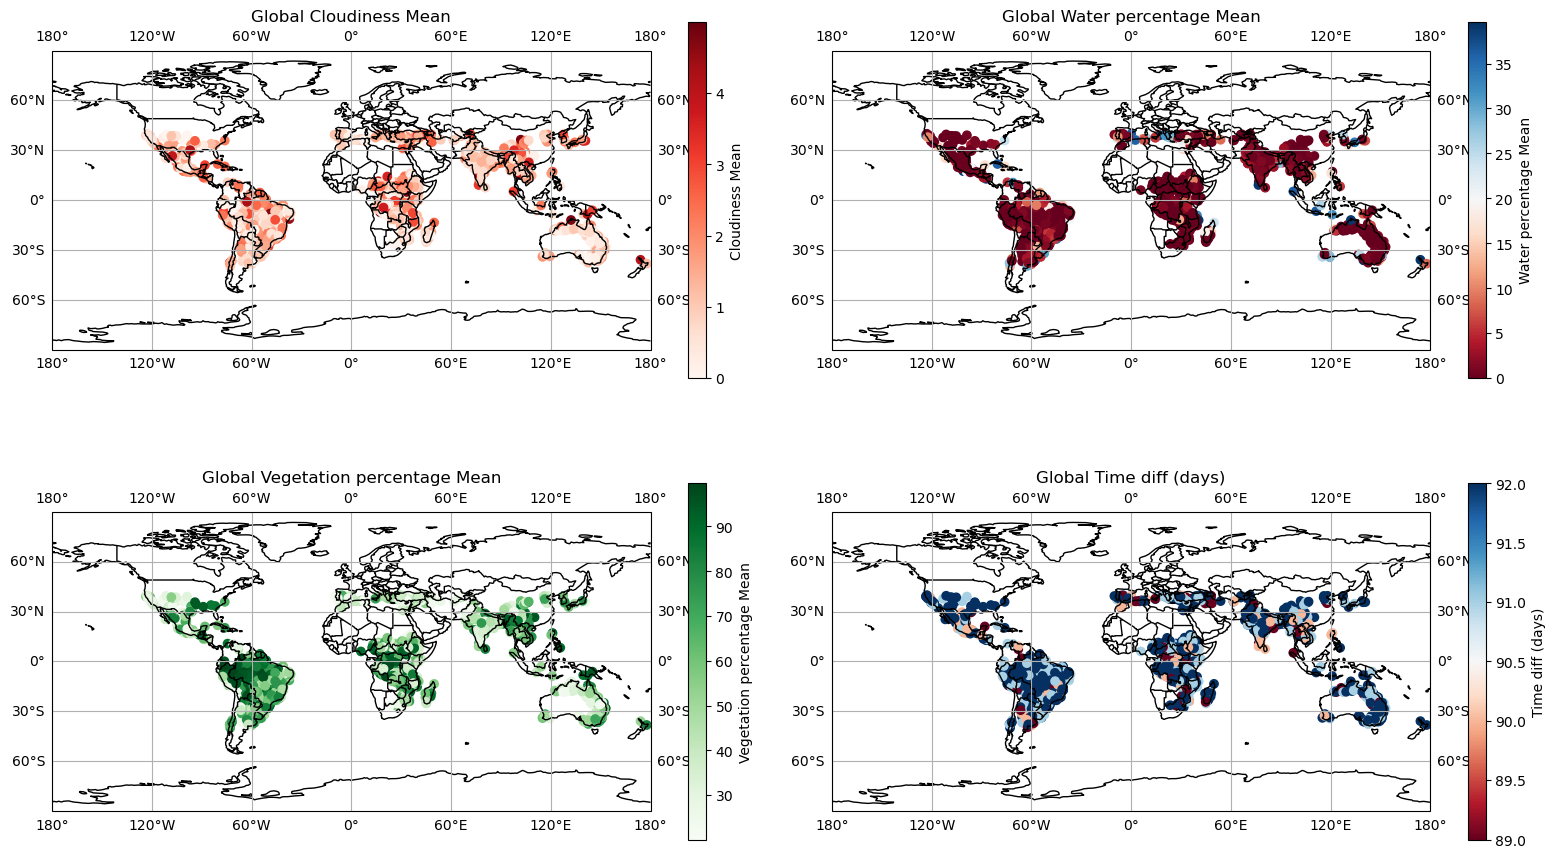

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), subplot_kw={"projection": ccrs.PlateCarree()})
color_columns = ["Cloudiness Mean", "Water percentage Mean", "Vegetation percentage Mean", "Time diff (days)"]
cmaps = ["Reds", "RdBu", "Greens", "RdBu"]
for i in range(len(color_columns)):

    axes[i // 2, i % 2].set_global()
    axes[i // 2, i % 2].coastlines()
    axes[i // 2, i % 2].add_feature(cfeature.BORDERS)
    axes[i // 2, i % 2].gridlines(draw_labels=True)
    scatter = axes[i // 2, i % 2].scatter(df["Longitudes"], df["Latitud"], c=df[color_columns[i]], cmap=cmaps[i])
    cbar = plt.colorbar(scatter, ax=axes[i // 2, i % 2], label=color_columns[i], shrink=0.7)
    axes[i // 2, i % 2].set_title(f"Global {color_columns[i]}")

plt.tight_layout()

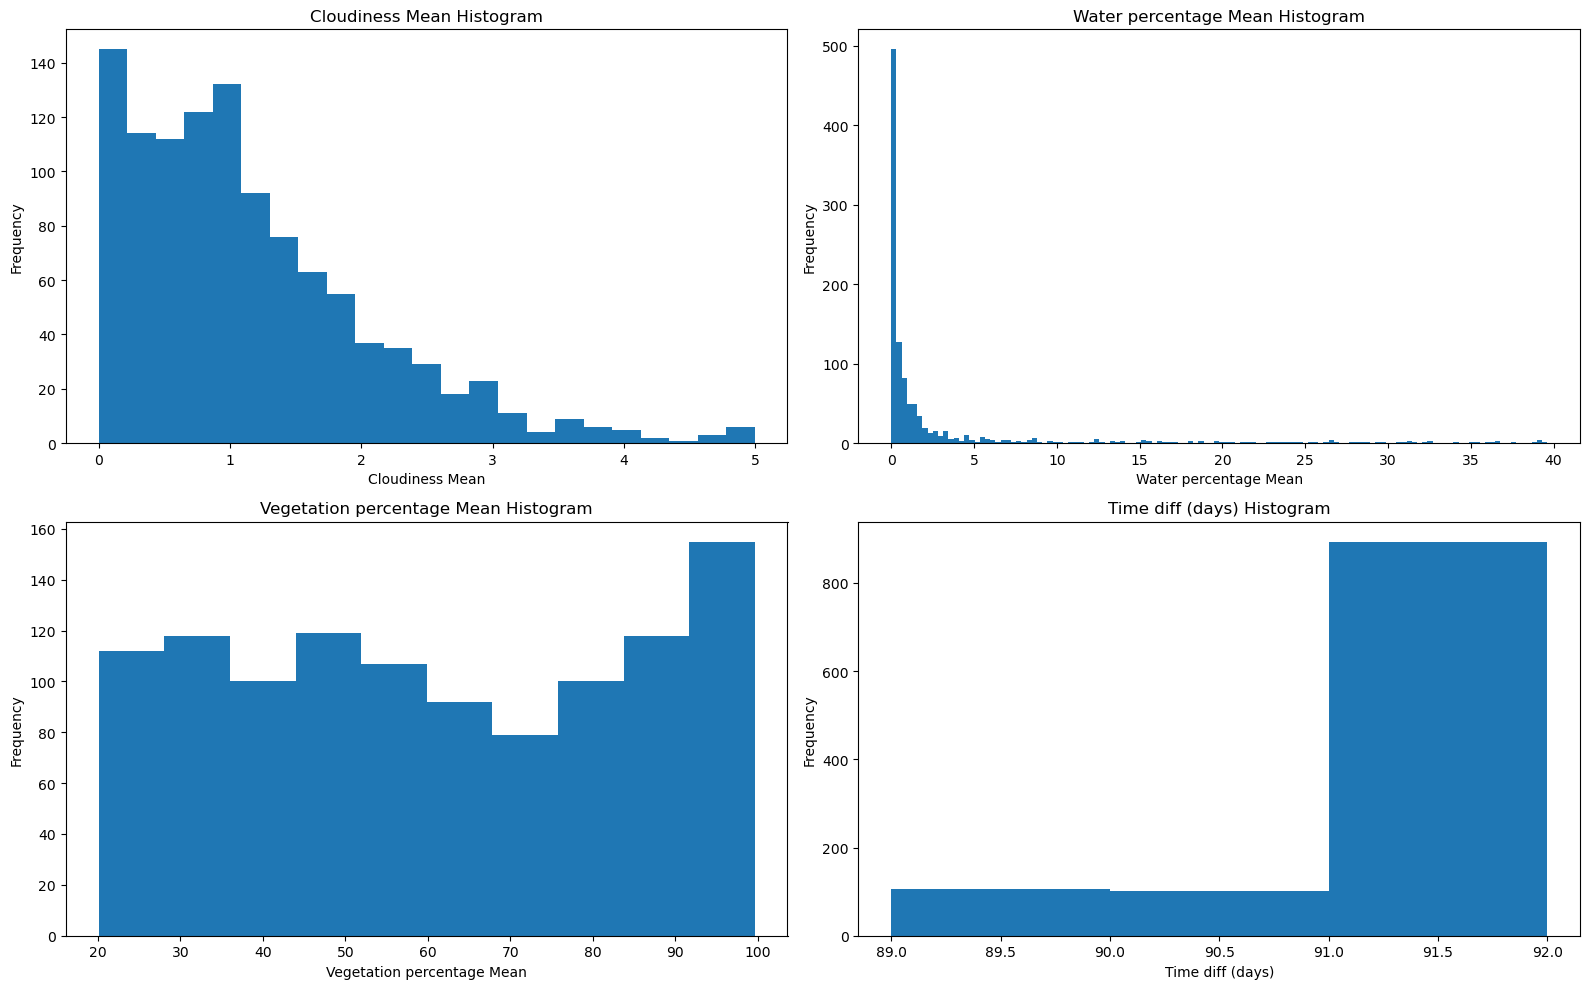

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for i in range(len(color_columns)):
    
    df[color_columns[i]].plot.hist(ax=axes[i // 2, i % 2], bins='fd')
    axes[i // 2, i % 2].set_xlabel(color_columns[i])
    axes[i // 2, i % 2].set_title(f"{color_columns[i]} Histogram")

plt.tight_layout()

In [25]:
print(df["Water percentage Mean"].max())

39.6090625


In terms of projected future uses (wildfire detection systems), some of these results are not as ideal. For this as a prototype, these results will be sufficient but a few notes on the maps:

- South America and South Africa are the most represented areas
- Most of the images are moderately cloudy to not cloudy at all - this would cause some issues with having the model being resilient to cloudiness.
- Vegetation values are within the range of around 30 - 100. Areas like deserts would cause some problems for the overall model, since there would be 0 vegetation
- Most of the areas sampled from has a low water percentage, which could represent fire risk areas.
- Time diff has a fairly small range, so time diff plot doesn't raise too many conclusions, although it's good to know that there's no specific places consistently undersampled from.

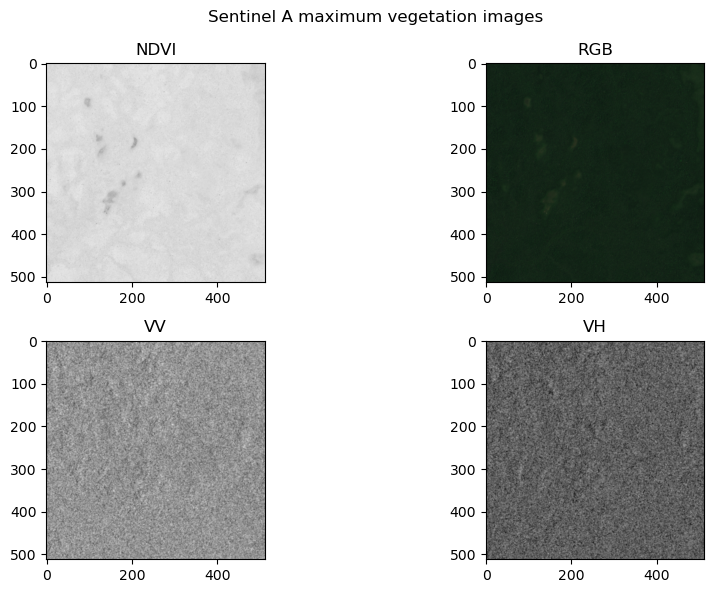

In [27]:
image_topveg_A = df.loc[df["Vegetation percentage Mean"].argmax(), "ID_A"]
image_topveg_B = df.loc[df["Vegetation percentage Mean"].argmax(), "ID_B"]

NDVI_image = Image.open(os.path.join(data_folder, NDVI_path, image_topveg_A))
RGB_image = Image.open(os.path.join(data_folder, RGB_path, image_topveg_A))
VV_image = Image.open(os.path.join(data_folder, VV_path, image_topveg_A))
VH_image = Image.open(os.path.join(data_folder, VH_path, image_topveg_A))
fig, ax = plt.subplots(2, 2, figsize=(10, 6))
plt.suptitle("Sentinel A maximum vegetation images")
ax[0, 0].imshow(Image.fromarray(np.asarray(NDVI_image) * 255))
ax[0, 0].set_title("NDVI")
ax[0, 1].imshow(RGB_image)
ax[0, 1].set_title("RGB")
ax[1, 0].imshow(VV_image)
ax[1, 0].set_title("VV")
ax[1, 1].imshow(VH_image)
ax[1, 1].set_title("VH")
plt.tight_layout()
plt.show()

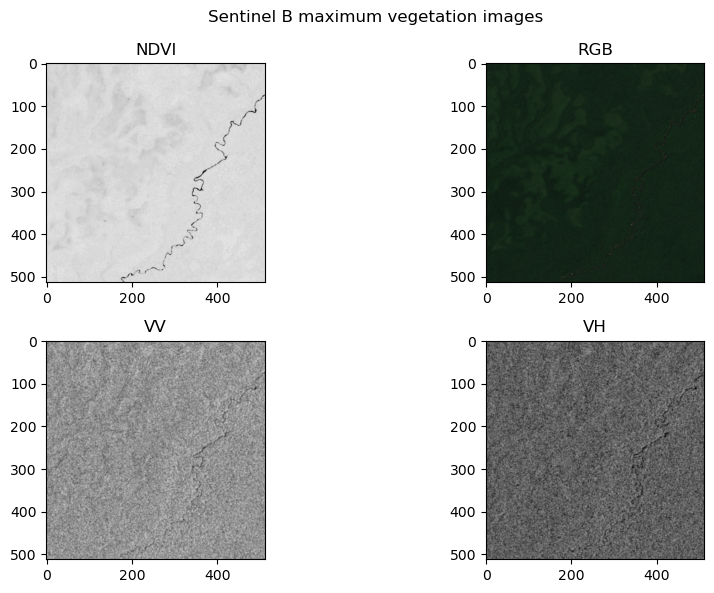

In [28]:
NDVI_image = Image.open(os.path.join(data_folder, NDVI_path, image_topveg_B))
RGB_image = Image.open(os.path.join(data_folder, RGB_path, image_topveg_B))
VV_image = Image.open(os.path.join(data_folder, VV_path, image_topveg_B))
VH_image = Image.open(os.path.join(data_folder, VH_path, image_topveg_B))
fig, ax = plt.subplots(2, 2, figsize=(10, 6))

plt.suptitle("Sentinel B maximum vegetation images")

ax[0, 0].imshow(Image.fromarray(np.asarray(NDVI_image) * 255))
ax[0, 0].set_title("NDVI")
ax[0, 1].imshow(RGB_image)
ax[0, 1].set_title("RGB")
ax[1, 0].imshow(VV_image)
ax[1, 0].set_title("VV")
ax[1, 1].imshow(VH_image)
ax[1, 1].set_title("VH")
plt.tight_layout()
plt.show()

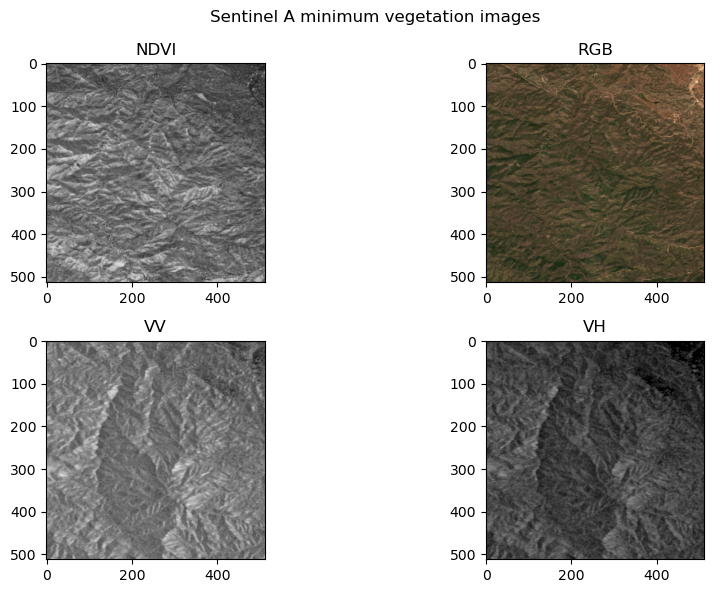

In [29]:
image_botveg_A = df.loc[df["Vegetation percentage Mean"].argmin(), "ID_A"]
image_botveg_B = df.loc[df["Vegetation percentage Mean"].argmin(), "ID_B"]

NDVI_image = Image.open(os.path.join(data_folder, NDVI_path, image_botveg_A))
RGB_image = Image.open(os.path.join(data_folder, RGB_path, image_botveg_A))
VV_image = Image.open(os.path.join(data_folder, VV_path, image_botveg_A))
VH_image = Image.open(os.path.join(data_folder, VH_path, image_botveg_A))
fig, ax = plt.subplots(2, 2, figsize=(10, 6))

plt.suptitle("Sentinel A minimum vegetation images")

ax[0, 0].imshow(Image.fromarray(np.asarray(NDVI_image) * 255))
ax[0, 0].set_title("NDVI")
ax[0, 1].imshow(RGB_image)
ax[0, 1].set_title("RGB")
ax[1, 0].imshow(VV_image)
ax[1, 0].set_title("VV")
ax[1, 1].imshow(VH_image)
ax[1, 1].set_title("VH")
plt.tight_layout()
plt.show()

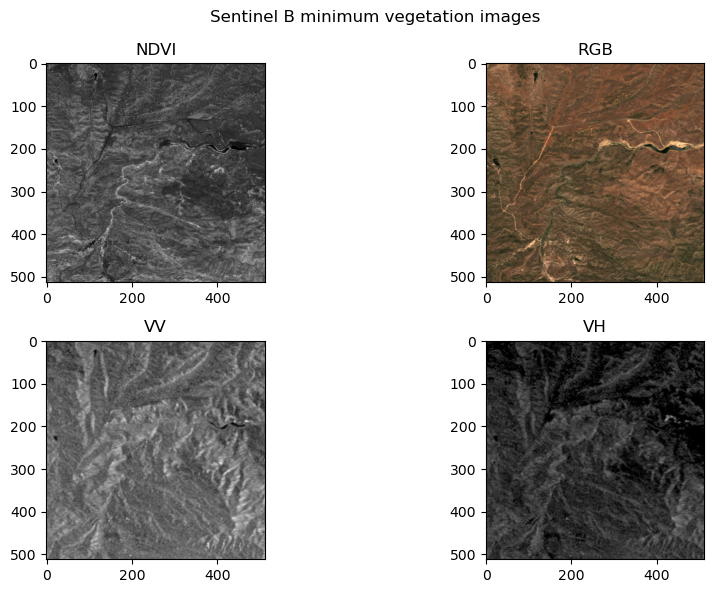

In [30]:
NDVI_image = Image.open(os.path.join(data_folder, NDVI_path, image_botveg_B))
RGB_image = Image.open(os.path.join(data_folder, RGB_path, image_botveg_B))
VV_image = Image.open(os.path.join(data_folder, VV_path, image_botveg_B))
VH_image = Image.open(os.path.join(data_folder, VH_path, image_botveg_B))
fig, ax = plt.subplots(2, 2, figsize=(10, 6))

plt.suptitle("Sentinel B minimum vegetation images")

ax[0, 0].imshow(Image.fromarray(np.asarray(NDVI_image) * 255))
ax[0, 0].set_title("NDVI")
ax[0, 1].imshow(RGB_image)
ax[0, 1].set_title("RGB")
ax[1, 0].imshow(VV_image)
ax[1, 0].set_title("VV")
ax[1, 1].imshow(VH_image)
ax[1, 1].set_title("VH")
plt.tight_layout()
plt.show()

By the images shown above, it's clear that the lesser vegetated areas are much less green, and the higher vegetated areas...a pretty obvious conclusion but one question I have is if the RGB images are enough to create these NDVI images. To find out, we can compute correlations between the green band of the RGB images and the NDVI intensities, as well as the VH/VV correlations with NDVI.

### Correlation Study

As mentioned earlier, a particular interesting correlation would be the green intensities to NDVI, those will be studied as well as the radar intensities to the NDVI.

Before doing the correlations, we must read in the data as torch tensor arrays.

In [147]:
device = "cuda" if torch.cuda.is_available() else "cpu"

class SentinelDataset(ImageFolder):

    def __init__(self, root, transform=None):

        self.root = root
        self.file_list = os.listdir(f"{root}/NDVI")
        self.grayscale_transform = transforms.Grayscale()
        self.transform = transform

    def __len__():
        
        return len(self.file_list)
    
    def __getitem__(self, index):

        RGB_image = Image.open(os.path.join(self.root, "RGB", self.file_list[index])).convert("RGB")
        VV_image = Image.open(os.path.join(self.root, "VV", self.file_list[index])).convert("L")
        VH_image = Image.open(os.path.join(self.root, "VH", self.file_list[index])).convert("L")
        NDVI_image = Image.open(os.path.join(self.root, "NDVI", self.file_list[index]))
        NDVI_image = Image.fromarray(np.asarray(NDVI_image) * 255)

        RGB_image = self.transform(RGB_image)
        VV_image = self.transform(VV_image)
        VH_image = self.transform(VH_image)
        NDVI_image = self.transform(NDVI_image)

        if len(RGB_image.size()) == 3:

            catdim = 0

        else:

            catdim = 1
            
        input_images = torch.cat([RGB_image, VV_image, VH_image], dim=catdim)
        
        return input_images, NDVI_image
        


Now, for the correlation. We will find the correlations between all the NVDI images to the RGB bands, the VH, and the VV. During this process, we will also grayscale the NDVI, VH, and VV images.

In [179]:
transform = transforms.Compose([
    transforms.Resize((224, 244)),
    transforms.ToTensor(),
])
dataset = SentinelDataset("Data", transform=transform)
correlations = [0, 0, 0, 0, 0]
black_images = [0, 0, 0, 0, 0]
for inputs, target in dataset:

    NVDI_image = target[0, :, :]
    for i in range(len(correlations)):

        coeff_number = torch.corrcoef(torch.stack([inputs[i, :, :].view(-1), NVDI_image.view(-1)]))[0, 1]

        if torch.isnan(coeff_number):

            black_images[i] += 1

        else:
        
            correlations[i] += coeff_number


print(f"Red Band: {correlations[0] / (2200 - black_images[}")
print(f"Green Band: {correlations[1] / 2200}")
print(f"Blue Band: {correlations[2] / 2200}")
print(f"VV Band: {correlations[3] / 2200}")
print(f"VH Band: {correlations[4] / (2200 - black_images)}")
    

Red Band: -0.7742452621459961
Green Band: -0.5870677828788757
Blue Band: -0.7105979323387146
VV Band: 0.339628130197525
VH Band: 0.42218753695487976


##### RGB bands

Surprisingly, the Green band actually has the weakest correlation (although still fairly strong), and the red / blue bands have stronger correlation to the NDVI. At first this confused me a bit, but this actually makes sense physically. The red band having a strong negative correlation makes sense since it's very analagous to infrared, which is used as the lack of vegetation in an image. Similarly here, the red band has a strong negative correlation because the higher the red intensity the lower the possibility of vegetation being in that certain pixel. Same goes for the blue pixels, but instead of lack of vegetation it's more so that there's water in that pixel instead of vegetation.

##### Radar Bands

Both VV and VH radar bands have positive correlations with the NDVI, but weaker correlations than the RGB